In [ ]:
# Uninstall the older versions first
!pip uninstall -y numpy pmdarima
# Install the modern versions that satisfy JAX, OpenCV, and pmdarima
# Instalamos la versión de NumPy que satisface a todos los paquetes
!pip install "numpy>=2.0,<2.1"
!pip install pmdarima

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.2 MB)


  Using cached pmdarima-2.1.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.5 kB)
Using cached pmdarima-2.1.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (689 kB)


In [ ]:
#import pandas as pd
from pmdarima import auto_arima
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"

In [ ]:
df = pd.read_csv(url)

In [ ]:
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [ ]:
df.dtypes

,0
date,object
sales,float64


In [ ]:
df['date'] =pd.to_datetime(df['date'])
df = df.set_index("date")

In [ ]:
df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


In [ ]:
modelo = auto_arima(df['sales'], seasonal=False,
                    stepwise=True,
                    trace=True)
print(modelo.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1843.162, Time=4.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2096.542, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1970.972, Time=0.37 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1839.586, Time=2.24 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2209.657, Time=0.14 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1839.552, Time=1.97 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1841.532, Time=2.46 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1843.586, Time=0.97 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1839.607, Time=1.25 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1922.648, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=inf, Time=0.52 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 14.306 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  366


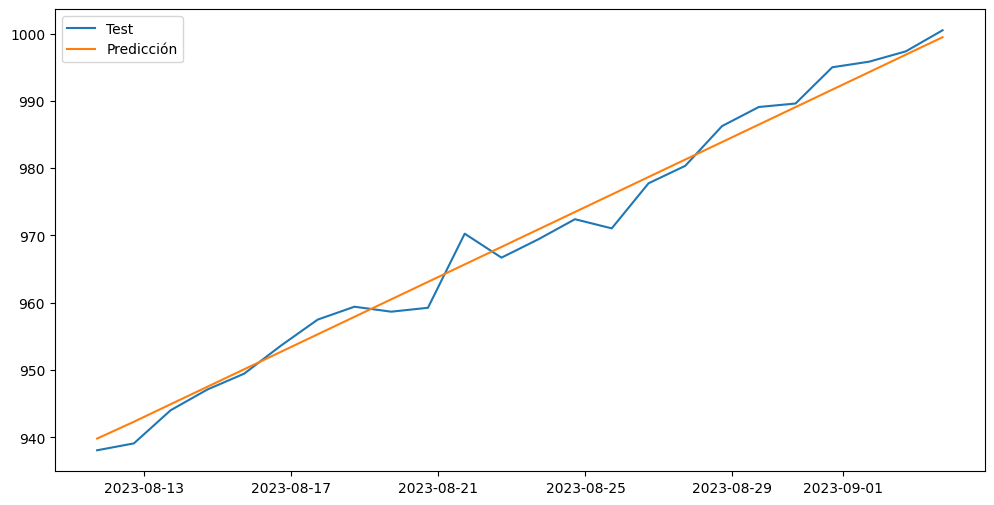

In [ ]:
train = df.iloc[:-24]  # Todo menos los últimos 12 dias..
test = df.iloc[-24:]   # Últimos 24 dias

modelo = auto_arima(train['sales'], seasonal=False, stepwise=True)
predicciones = modelo.predict(n_periods=len(test))

# Comparar visualmente
plt.figure(figsize=(12,6))
plt.plot(test.index, test['sales'], label="Test")
plt.plot(test.index, predicciones, label="Predicción")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(test['sales'], predicciones))
print(f"RMSE: {rmse}")

RMSE: 2.255270034789724


In [ ]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(test['sales'], predicciones)

1.863314655112826

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(test['sales'], predicciones)

0.0019231020102485452

In [ ]:
forecast = modelo.predict(3)

In [ ]:
forecast

,0
2023-08-11 17:10:08.079328,939.813289
2023-08-12 17:10:08.079328,942.309144
2023-08-13 17:10:08.079328,944.916051
